In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stocks = ["RELIANCE", "TCS", "HDFCBANK", "SUNPHARMA", "INFY"]

data = {}

for stock in stocks:
    df = pd.read_csv(f"../data/raw/{stock}.csv", index_col=0, parse_dates=True)
    data[stock] = df

/tmp/ipykernel_45443/1812024221.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{stock}.csv", index_col=0, parse_dates=True)
/tmp/ipykernel_45443/1812024221.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{stock}.csv", index_col=0, parse_dates=True)
/tmp/ipykernel_45443/1812024221.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{stock}.csv", index_col=0, parse_dates=True)
/tmp/ipykernel_45443/1812024221.py:6: UserWarning: Could not infer format, so each element will be p

In [4]:
for stock in stocks:
    data[stock]["Close"] = pd.to_numeric(data[stock]["Close"], errors="coerce")

In [5]:
for stock in stocks:
    data[stock]["Returns"] = data[stock]["Close"].pct_change()

In [6]:
for stock in stocks:
    data[stock]["RollingVol"] = data[stock]["Returns"].rolling(window=20).std()

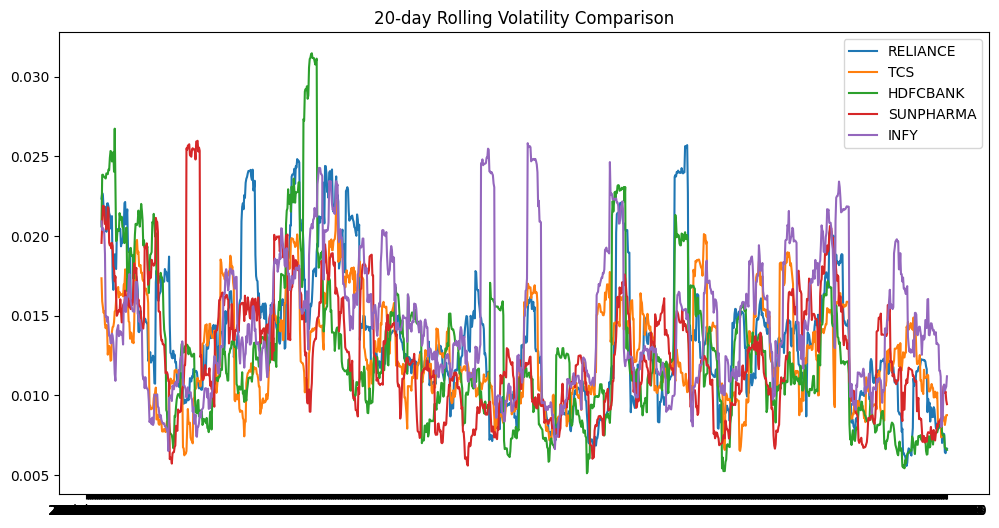

In [7]:
plt.figure(figsize=(12,6))

for stock in stocks:
    plt.plot(data[stock]["RollingVol"], label=stock)

plt.title("20-day Rolling Volatility Comparison")
plt.legend()
plt.show()

In [8]:
vol_scores = {}

for stock in stocks:
    vol_scores[stock] = data[stock]["Returns"].std()

vol_scores = dict(sorted(vol_scores.items(), key=lambda x: x[1], reverse=True))
vol_scores

{'INFY': np.float64(0.015165847421210988),
 'RELIANCE': np.float64(0.014315522220262089),
 'HDFCBANK': np.float64(0.013382617474694406),
 'SUNPHARMA': np.float64(0.013190468368876593),
 'TCS': np.float64(0.013075371051016017)}

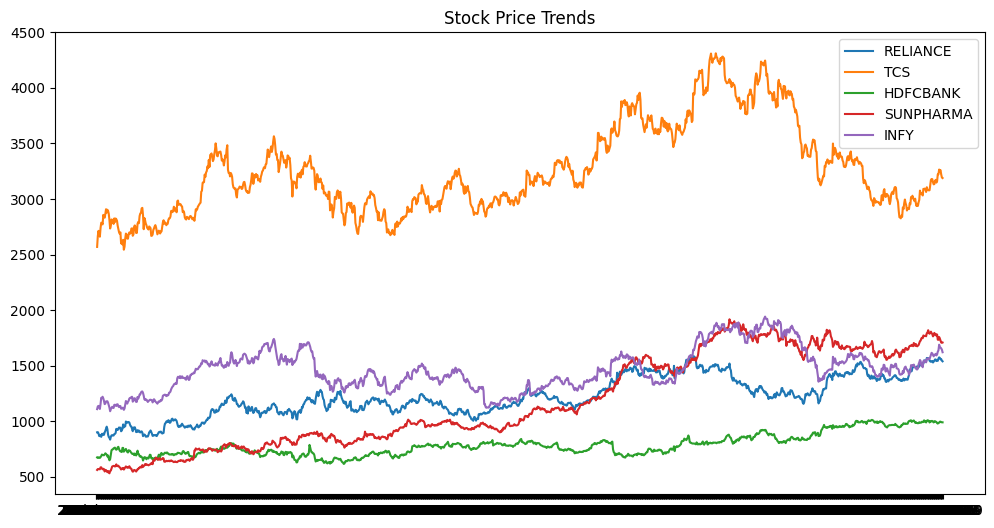

In [9]:
plt.figure(figsize=(12,6))

for stock in stocks:
    plt.plot(data[stock]["Close"], label=stock)

plt.title("Stock Price Trends")
plt.legend()
plt.show()

In [10]:
close_df = pd.DataFrame()

for stock in stocks:
    close_df[stock] = data[stock]["Close"]

corr = close_df.pct_change().corr()
corr

,RELIANCE,TCS,HDFCBANK,SUNPHARMA,INFY
RELIANCE,1.000000,0.295408,0.363906,0.233912,0.278243
TCS,0.295408,1.000000,0.227717,0.215664,0.699586
HDFCBANK,0.363906,0.227717,1.000000,0.187710,0.260130
SUNPHARMA,0.233912,0.215664,0.187710,1.000000,0.205344
INFY,0.278243,0.699586,0.260130,0.205344,1.000000


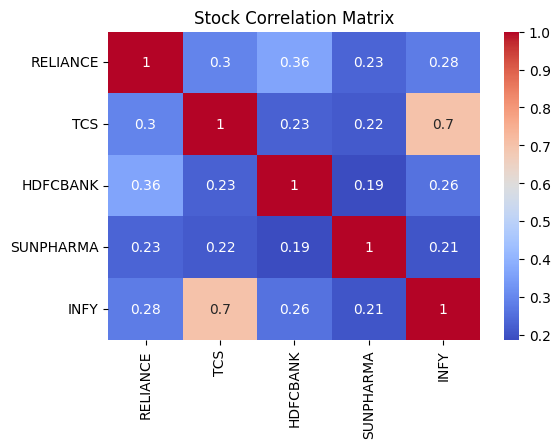

In [11]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Stock Correlation Matrix")
plt.show()